FIRST 5 ROWS OF DATASET
  ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0  5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...                                                                                                                                                                                                                                                                                                                                                  
1  2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...                                                                                                                                              

/tmp/ipykernel_7447/3405545258.py:184: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7447/3405545258.py:184: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_7447/3405545258.py:186: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig("missing_values_report.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


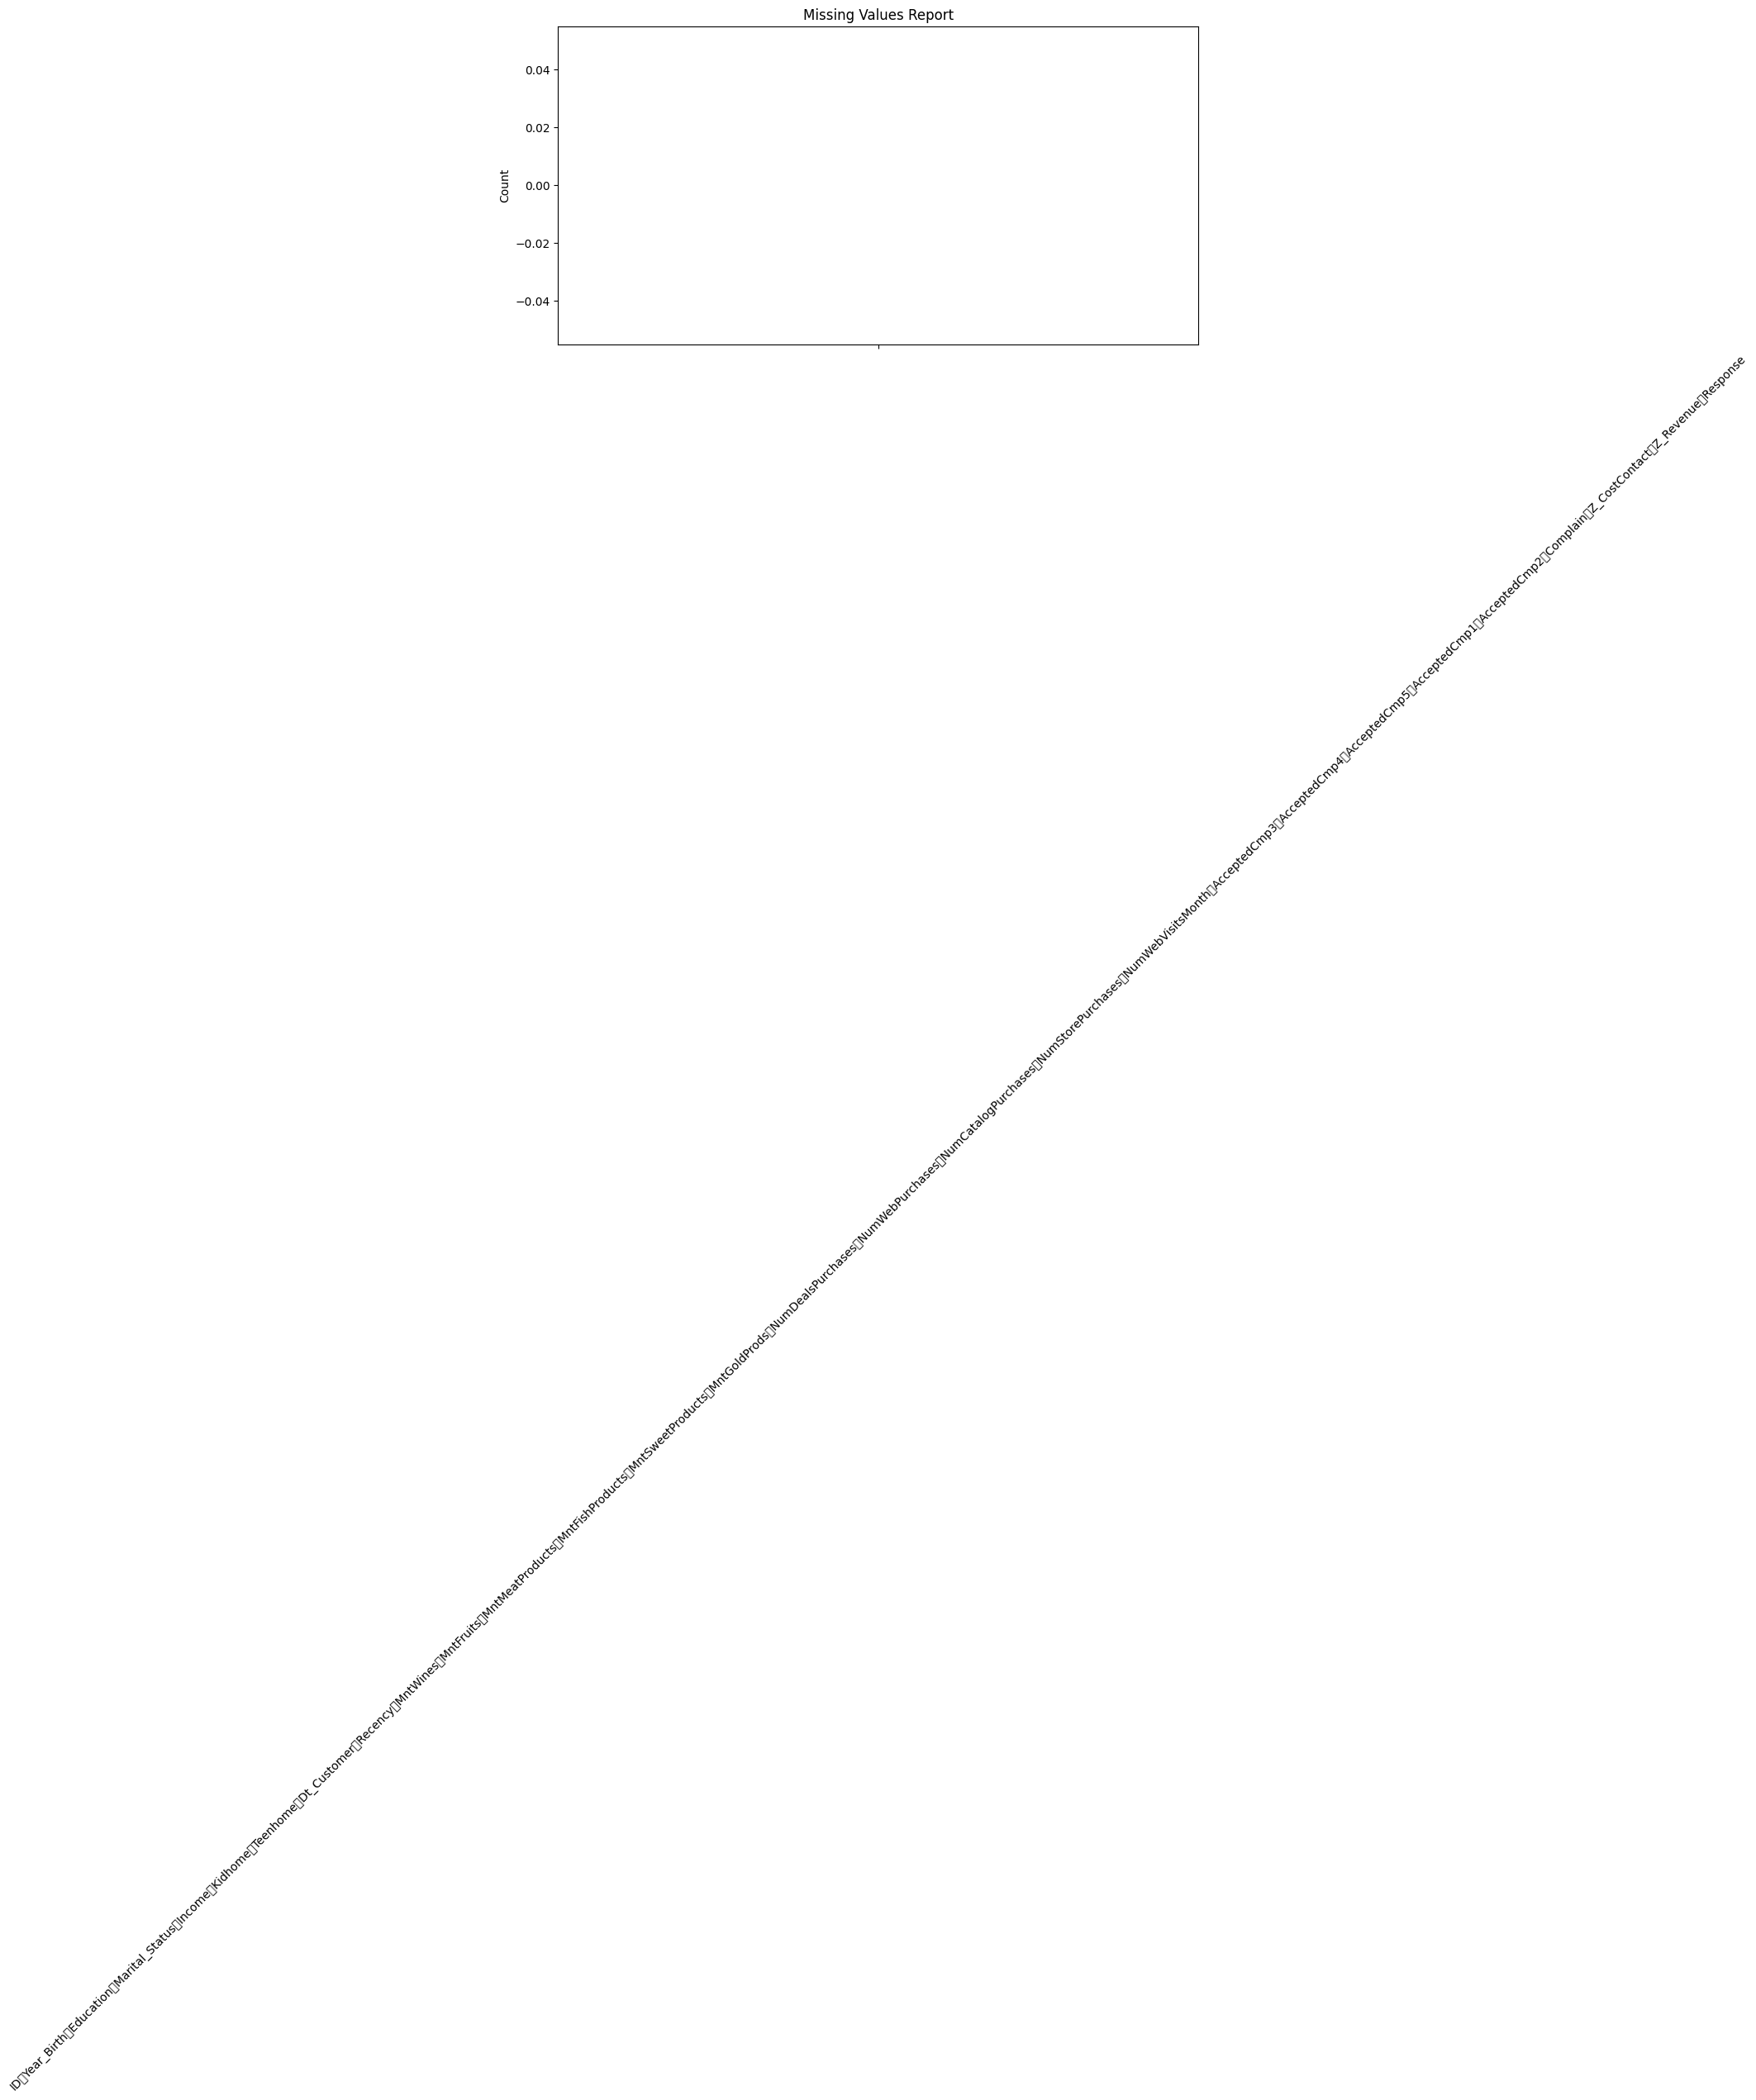


Cleaned Dataset Saved Successfully

AUTOMATED REPORTS GENERATED
Generated Files:
1. cleaned_marketing_campaign.csv
2. summary_report.csv
3. correlation_report.csv
4. histogram_visualization.png
5. bar_chart_summary.png
6. missing_values_report.png
7. automation_report.txt

PROJECT EXECUTED SUCCESSFULLY


In [5]:
# ==========================================
# DATA CLEANING & REPORTING AUTOMATION
# ==========================================

# STEP 1 - IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 2 - LOAD DATASET
# ==========================================

data = pd.read_csv("marketing_campaign.csv")

print("===================================")
print("FIRST 5 ROWS OF DATASET")
print("===================================")

print(data.head())

# ==========================================
# STEP 3 - DATASET INFORMATION
# ==========================================

print("\n===================================")
print("DATASET INFORMATION")
print("===================================")

print(data.info())

print("\n===================================")
print("MISSING VALUES")
print("===================================")

print(data.isnull().sum())

# ==========================================
# STEP 4 - DATA CLEANING
# ==========================================

# REMOVE DUPLICATES

before_rows = data.shape[0]

data = data.drop_duplicates()

after_rows = data.shape[0]

print("\nDuplicates Removed:", before_rows - after_rows)

# HANDLE MISSING VALUES

# Fill text columns with "Unknown"

text_columns = data.select_dtypes(include=['object']).columns

for column in text_columns:
    data[column] = data[column].fillna("Unknown")

# Convert possible numeric columns

for column in data.columns:
    try:
        data[column] = pd.to_numeric(data[column])
    except:
        pass

# Fill numeric missing values with mean

numeric_columns = data.select_dtypes(include=np.number).columns

for column in numeric_columns:
    data[column] = data[column].fillna(data[column].mean())

print("\n===================================")
print("DATA CLEANING COMPLETED")
print("===================================")

print(data.isnull().sum())

# ==========================================
# STEP 5 - AUTOMATED SUMMARY REPORT
# ==========================================

summary = data.describe(include='all')

print("\n===================================")
print("SUMMARY REPORT")
print("===================================")

print(summary)

# Save Summary Report

summary.to_csv("summary_report.csv")

# ==========================================
# STEP 6 - CORRELATION REPORT
# ==========================================

numeric_data = data.select_dtypes(include=np.number)

if numeric_data.shape[1] > 0:

    correlation = numeric_data.corr()

    print("\n===================================")
    print("CORRELATION MATRIX")
    print("===================================")

    print(correlation)

    correlation.to_csv("correlation_report.csv")

# ==========================================
# STEP 7 - VISUAL SUMMARY 1
# HISTOGRAMS
# ==========================================

if numeric_data.shape[1] > 0:

    numeric_data.hist(figsize=(14,10))

    plt.suptitle("Marketing Campaign Data Distribution")

    plt.savefig("histogram_visualization.png")

    plt.show()

# ==========================================
# STEP 8 - VISUAL SUMMARY 2
# BAR CHART
# ==========================================

if numeric_data.shape[1] > 0:

    mean_values = numeric_data.mean()

    if len(mean_values) > 0:

        plt.figure(figsize=(12,6))

        mean_values.plot(kind='bar')

        plt.title("Average Values of Numerical Columns")

        plt.ylabel("Average Value")

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.savefig("bar_chart_summary.png")

        plt.show()

    else:

        print("No mean values available for bar chart")

else:

    print("No numeric columns available")

# ==========================================
# STEP 9 - VISUAL SUMMARY 3
# MISSING VALUES CHART
# ==========================================

missing_values = data.isnull().sum()

plt.figure(figsize=(10,5))

missing_values.plot(kind='bar')

plt.title("Missing Values Report")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("missing_values_report.png")

plt.show()

# ==========================================
# STEP 10 - SAVE CLEANED DATASET
# ==========================================

data.to_csv("cleaned_marketing_campaign.csv", index=False)

print("\nCleaned Dataset Saved Successfully")

# ==========================================
# STEP 11 - GENERATE AUTOMATED TEXT REPORT
# ==========================================

report = open("automation_report.txt", "w")

report.write("=====================================\n")
report.write("DATA CLEANING & REPORTING AUTOMATION\n")
report.write("=====================================\n\n")

report.write(f"Total Rows: {data.shape[0]}\n")
report.write(f"Total Columns: {data.shape[1]}\n\n")

report.write("Missing Values After Cleaning:\n")
report.write(str(data.isnull().sum()))

report.write("\n\nSummary Report Generated Successfully")

report.close()

# ==========================================
# STEP 12 - FINAL OUTPUT
# ==========================================

print("\n===================================")
print("AUTOMATED REPORTS GENERATED")
print("===================================")

print("Generated Files:")
print("1. cleaned_marketing_campaign.csv")
print("2. summary_report.csv")
print("3. correlation_report.csv")
print("4. histogram_visualization.png")
print("5. bar_chart_summary.png")
print("6. missing_values_report.png")
print("7. automation_report.txt")

print("\nPROJECT EXECUTED SUCCESSFULLY")